## Gradient data with Peltier on one side and RT on other

note: it was difficult to keep the RT side consistent, so analysis tries to take temperature gaps into account as well as whether the battery was heating or cooling

In [2]:
import sys
sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/ultrasonicTesting')

import pickleJar as pj
import sqliteUtils as squ
import numpy as np
from numpy import fft
import os.path
import matplotlib.pyplot as plt

In [3]:
# First we load the data from the file we want to analyze
# The experiment should always output sqlite3 files, so let's convert them to a more usable pickle form first
sqliteFile = "/Users/xz498/Desktop/ultrasound project/data analysis/gradient_data/xz_pouch_cell_transmission_gradient_rt_60_rt.sqlite3"

# Convert the sqlite3 to a .pickle
# This takes a few seconds. A progress bar will display in your terminal
pj.sqliteToPickle(sqliteFile)

# Load the pickle
pickleFile = os.path.splitext(sqliteFile)[0] + '.pickle'

100%|██████████| 1198/1198 [00:00<00:00, 3518.90it/s]


In [4]:
data = pj.loadPickle("/Users/xz498/Desktop/ultrasound project/data analysis/gradient_data/xz_pouch_cell_transmission_gradient_rt_60-50.pickle")

In [5]:
# for k, v in data.items():
#         print("key:",k, "type:", type(v))
#         if isinstance(v, dict):
#             for k2, v2 in v.items():
#                 print("\tkey:",k2, "type:", type(v2))

In [6]:
## Very slow on laptop
# import plotly.graph_objects as go
# from ipywidgets import interact
# import ipywidgets as widgets
# from datetime import datetime
# import matplotlib.cm as cm

# def plot_waveform(i):
#     fig = go.Figure()
#     fig.add_trace(go.Scatter(x=data[i]['time'], y=data[i]['voltage'], mode='lines'))
#     fig.update_layout(
#         title=f'Measurement {i} at ({datetime.fromtimestamp(data[i]["time_collected"]).strftime("%Y-%m-%d, %H:%M:%S")})',
#         xaxis_title='Time (ns)',
#         yaxis_title='Voltage (mV)'
#     )
#     fig.show()

# # slider = widgets.IntSlider(
# #     value=0,
# #     min=0,
# #     max=len(data) - 2,
# #     step=1,
# #     description='measurement:',
# #     continuous_update=False
# # )

# # interact(plot_waveform, i=slider)

In [7]:
import plotly.graph_objects as go
# from ipywidgets import interact
# import ipywidgets as widgets
# from datetime import datetime
# import matplotlib.cm as cm

# def plot_waveform(i):
#     fig = go.Figure()
#     fig.add_trace(go.Scatter(x=data[i]['time'], y=data[i]['voltage'], mode='lines'))
#     fig.update_layout(
#         title=f'Measurement {i} at ({datetime.fromtimestamp(data[i]["time_collected"]).strftime("%Y-%m-%d, %H:%M:%S")})',
#         xaxis_title='Time (ns)',
#         yaxis_title='Voltage (mV)'
#     )
#     fig.show()

# # slider = widgets.IntSlider(
# #     value=0,
# #     min=0,
# #     max=len(data) - 2,
# #     step=1,
# #     description='measurement:',
# #     continuous_update=False
# # )

# # interact(plot_waveform, i=slider)

## Merge the waveform and controller data wrt time that UT is running

In [8]:
import pandas as pd
measurements = {k:v for k,v in data.items() if isinstance(k, int)}
waveform_df = pd.DataFrame(measurements).transpose()
# waveform_df['time_collected'] = waveform_df['time_collected'].astype(str)
waveform_df.head()

,voltage,time,time_collected,collection_index
0,"[0.13749876968503935, -0.025672982283464568, -...","[1000.0, 1002.0, 1004.0, 1006.0, 1008.0, 1010....",1774442998.491844,0.0
1,"[0.12052411417322835, -0.038838582677165355, -...","[1000.0, 1002.0, 1004.0, 1006.0, 1008.0, 1010....",1774442999.398435,1.0
2,"[0.14304133858267715, -0.04470595472440945, -0...","[1000.0, 1002.0, 1004.0, 1006.0, 1008.0, 1010....",1774443000.500211,2.0
3,"[0.14926919291338583, -0.000717273622047244, -...","[1000.0, 1002.0, 1004.0, 1006.0, 1008.0, 1010....",1774443001.499471,3.0
4,"[0.14510457677165356, -0.027401574803149604, -...","[1000.0, 1002.0, 1004.0, 1006.0, 1008.0, 1010....",1774443002.443846,4.0


In [9]:
# waveform_df['time_collected'] = waveform_df['time_collected'].apply(lambda x: datetime.fromtimestamp(x).strftime("%Y-%m-%d, %H:%M:%S"))
# pd.to_datetime(waveform_df['time_collected'])
waveform_df.tail()

,voltage,time,time_collected,collection_index
1792,"[-0.03431102362204724, -0.21968626968503938, -...","[1000.0, 1002.0, 1004.0, 1006.0, 1008.0, 1010....",1774444792.712927,1792.0
1793,"[-0.042301919291338586, -0.218626968503937, -0...","[1000.0, 1002.0, 1004.0, 1006.0, 1008.0, 1010....",1774444793.71984,1793.0
1794,"[-0.04402312992125983, -0.22936638779527557, -...","[1000.0, 1002.0, 1004.0, 1006.0, 1008.0, 1010....",1774444794.712495,1794.0
1795,"[-0.04677165354330708, -0.22278666338582676, -...","[1000.0, 1002.0, 1004.0, 1006.0, 1008.0, 1010....",1774444795.725599,1795.0
1796,"[-0.024639517716535435, -0.21723917322834646, ...","[1000.0, 1002.0, 1004.0, 1006.0, 1008.0, 1010....",1774444796.723135,1796.0


In [10]:
keep_cols = ['Time', 'Milliseconds',
             '1000.1: CH1 Object', '1000.2: CH2 Object', 
             '1045.1: HR1 Temp', '1045.2: HR2 Temp', 
            #  '2010.1: Output Enable', '2010.2: Output Enable', 
            #  '3034.1: Peltier Polarity', '3034.2: Peltier Polarity',
            #  '3050.1: Lower Boundary', '3050.2: Lower Boundary',
            #  '3051.1: CH1 Ramp', '3051.2: CH2 Ramp'
             ]
# to correct later: PID params, max temperature change, 

In [12]:
from datetime import datetime
controller_df = pd.read_csv('/Users/xz498/Desktop/ultrasound project/data analysis/gradient_data/CoSo_2026-03-25_10-15-38_Monitor.csv',
                            delimiter=';',usecols=keep_cols)
controller_df['Time'] = controller_df['Time'].apply(lambda x: datetime.strptime(x, '%m/%d/%Y %I:%M:%S %p').timestamp())
controller_df['Time'] += controller_df['Milliseconds']/1000
controller_df.drop(columns=['Milliseconds'], inplace=True)
controller_df['Time'] = controller_df['Time'].astype('O')

In [13]:
controller_df.tail()

,Time,1000.1: CH1 Object,1000.2: CH2 Object,1045.1: HR1 Temp,1045.2: HR2 Temp
3595,1774448151.921,32.544365,33.221123,32.544365,33.221123
3596,1774448152.921,32.528313,33.206200,32.528313,33.206200
3597,1774448153.915,32.512108,33.190788,32.512108,33.190788
3598,1774448154.917,32.497581,33.178246,32.497581,33.178246
3599,1774448155.93,32.482323,33.162407,32.482323,33.162407


In [14]:
waveform_df['time_collected'] = waveform_df['time_collected'].astype(float)
controller_df['Time'] = controller_df['Time'].astype(float)



In [15]:
merged_df = pd.merge_asof(
    left=waveform_df,
    right=controller_df,
    left_on='time_collected',
    right_on='Time',
    direction='nearest' 
)


In [16]:
merged_df.to_csv('/Users/xz498/Desktop/ultrasound project/data analysis/gradient_data/merged_df.csv')

In [17]:
merged_df.head()

,voltage,time,time_collected,collection_index,Time,1000.1: CH1 Object,1000.2: CH2 Object,1045.1: HR1 Temp,1045.2: HR2 Temp
0,"[0.13749876968503935, -0.025672982283464568, -...","[1000.0, 1002.0, 1004.0, 1006.0, 1008.0, 1010....",1.774443e+09,0.0,1.774445e+09,31.807886,32.681877,31.807886,32.681877
1,"[0.12052411417322835, -0.038838582677165355, -...","[1000.0, 1002.0, 1004.0, 1006.0, 1008.0, 1010....",1.774443e+09,1.0,1.774445e+09,31.807886,32.681877,31.807886,32.681877
2,"[0.14304133858267715, -0.04470595472440945, -0...","[1000.0, 1002.0, 1004.0, 1006.0, 1008.0, 1010....",1.774443e+09,2.0,1.774445e+09,31.807886,32.681877,31.807886,32.681877
3,"[0.14926919291338583, -0.000717273622047244, -...","[1000.0, 1002.0, 1004.0, 1006.0, 1008.0, 1010....",1.774443e+09,3.0,1.774445e+09,31.807886,32.681877,31.807886,32.681877
4,"[0.14510457677165356, -0.027401574803149604, -...","[1000.0, 1002.0, 1004.0, 1006.0, 1008.0, 1010....",1.774443e+09,4.0,1.774445e+09,31.807886,32.681877,31.807886,32.681877


## Compare Curves of gradients vs means

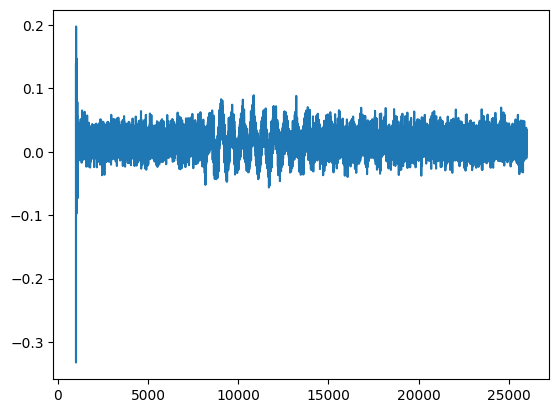

In [25]:
plt.plot(merged_df['time'][0],merged_df['voltage'][0])

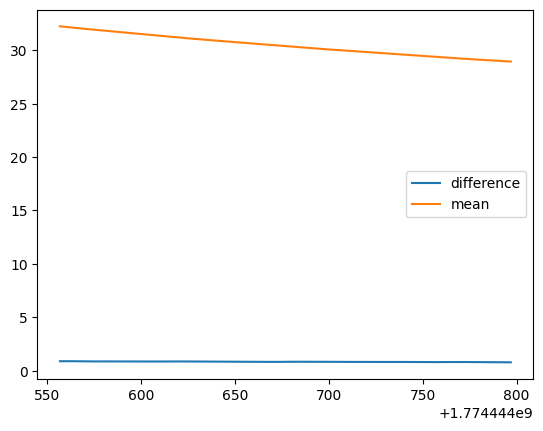

In [26]:
merged_df['means'] = merged_df[['1000.1: CH1 Object', '1000.2: CH2 Object']].mean(axis=1)
merged_df['diff'] = merged_df['1000.2: CH2 Object'] - merged_df['1000.1: CH1 Object']
plt.plot(merged_df['Time'], merged_df['diff'],label='difference')
plt.plot(merged_df['Time'], merged_df['means'],label='mean')
plt.legend()
plt.show()


/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_43401/1209300480.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('viridis')


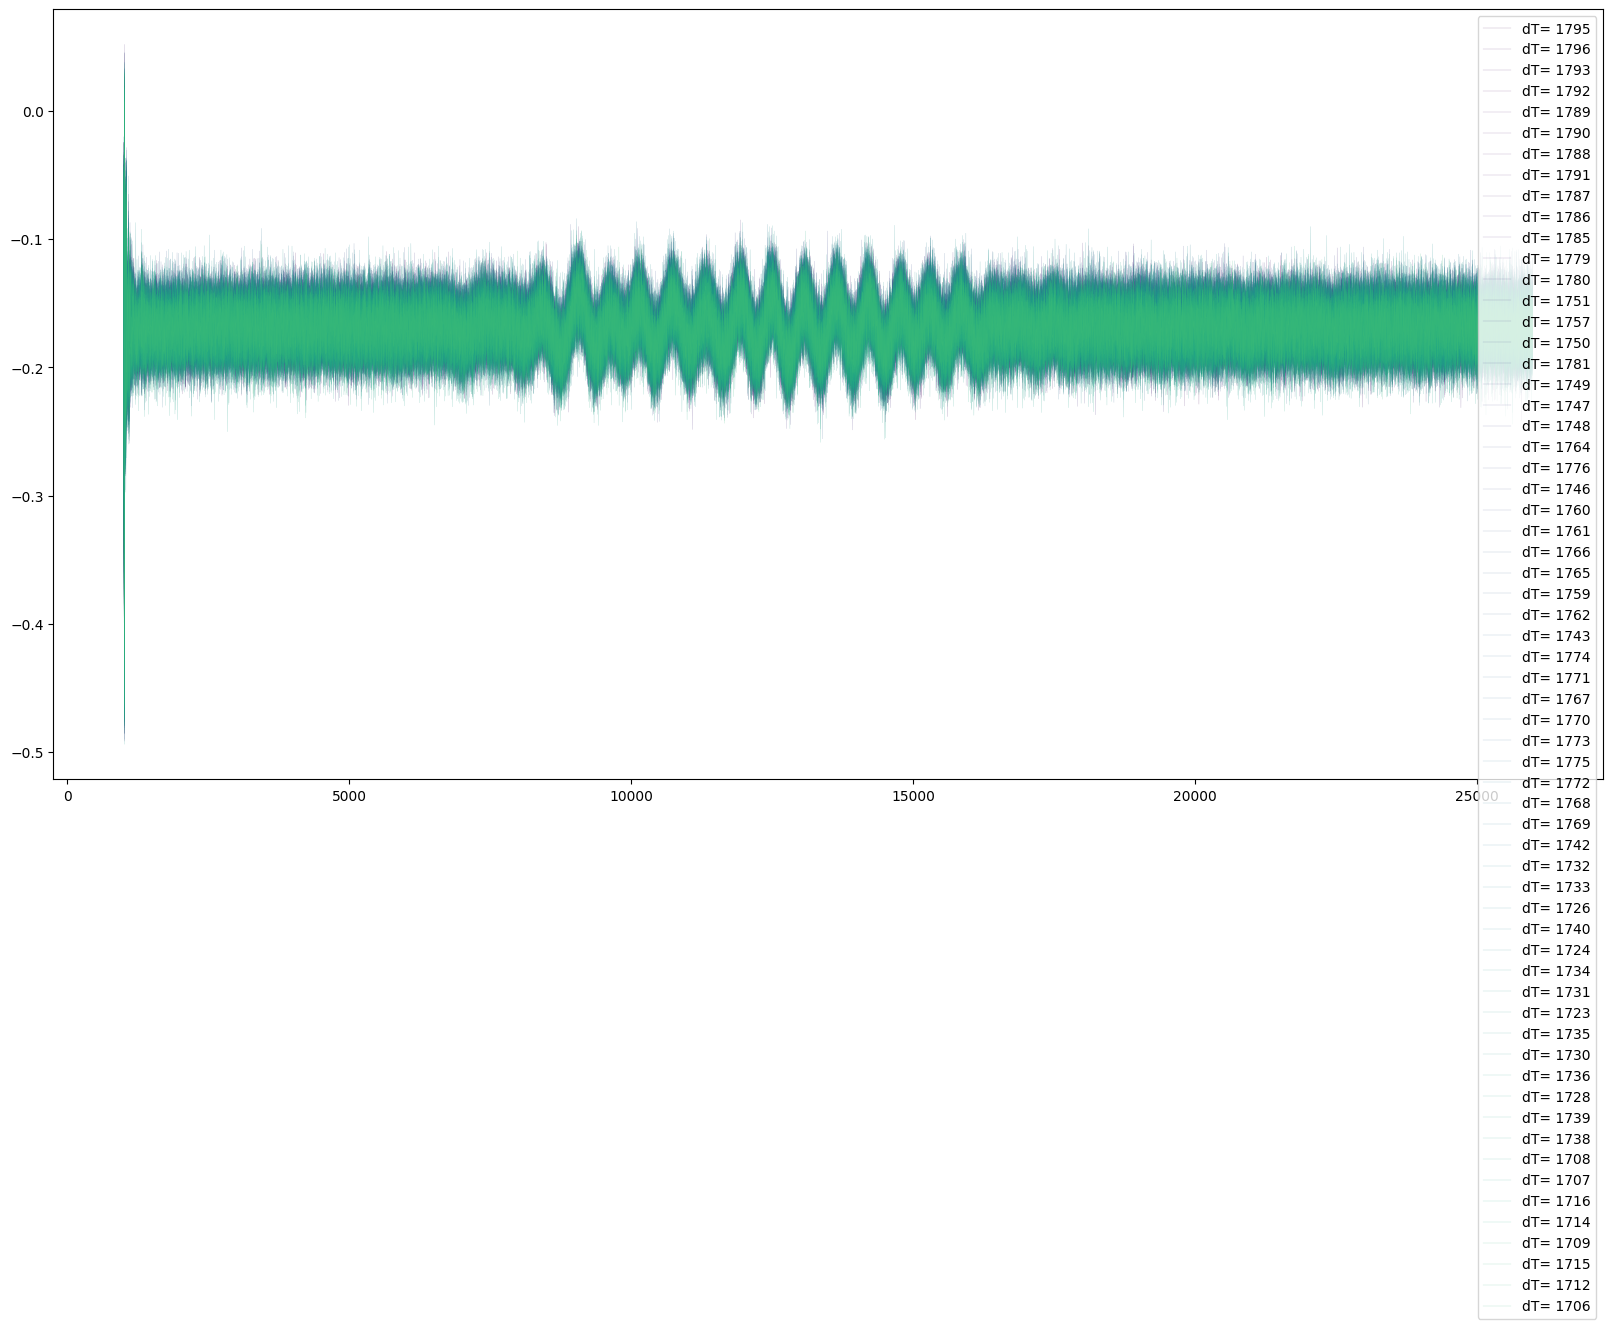

In [29]:
import matplotlib.cm as cm
viridis = cm.get_cmap('viridis')
ranged_df = merged_df[(20<=merged_df['means']) & (merged_df['means']<30)]
ranged_df.sort_values(by='diff',inplace=True)

i=0
fig, ax = plt.subplots(figsize=(20, 10))
for times,voltages in zip(ranged_df['time'].items(), ranged_df['voltage'].items()):
    if voltages[1].max()>0:
        color_val = i/len(ranged_df)
        ax.plot(times[1],voltages[1],label=f'dT= {ranged_df['collection_index'][times[0]]:.0f}', linewidth=0.1, color=viridis(color_val))
        i+=1
ax.legend()
